# Lab 8 : Star Formation 

In [6]:
import numpy as np
from astropy import units as u
from astropy import constants as const

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%matplotlib inline

# Part A

Create a function that returns the SFR for a given luminosity (NUV, FUV, TIR, Halpha)

$Log( {\rm SFR} (M_\odot/year)) = Log(Lx (erg/s)) - Log(Cx)$ 

Including corrections for dust absorption 

Kennicutt & Evans 2012 ARA&A Equation 12 and Table 1, 2

In [7]:
def StarFormationRate(L, Type, TIR=0):
    """Function that computes the star formation rate of a galaxy following Kennicutt and Evans 2012 Eq 12 (ARA&A 50).
    
    PARAMETERS
    ----------
        L: 'float' - luminosity of the galaxy in ergs/s
        Type: 'string' - the wavelength: 'FUV', 'UV', 'TIR', 'Halpha'
        TIR: 'float' - total infrared luminosity in ergs/s (default=0)
    OUTPUT
    ------
        SFR: 'float' - log of the star formation rate (Msun/yr)
    """
    #use table from 3/25 lecture
    if (Type == 'FUV'):
        logCx = 43.35 #Calibration from LFUV to SFR
        TIRc = 0.46 #dust absorption correction
    elif (Type == 'NUV'):
        logCx = 43.17
        TIRc = 0.27
    elif (Type == 'Halpha'):
        logCx = 41.27
        TIRc = 0.0024
    elif (Type == 'TIR'):
        logCx = 43.41
        TIRc = 0 #no correction here
    else:
        print("WARNING: Missing the Wavelength. I was expecting FUV, NUV, Halpha, TIR")
    
    #Correct the luminosity doe dust using the TIR
    Lcorr = L + TIRc*TIR
    
    #star formation rate
    SFR = np.log10(Lcorr) - logCx
    
    return SFR

Let's try to reproduce SFRs derived for the WLM Dwarf Irregular Galaxy using UV luminosities measured with Galex. 

Compare results to Table 1 from Lee et al. 2009 (who used the older Kennicutt 98 methods)
https://ui.adsabs.harvard.edu/abs/2009ApJ...706..599L/abstract

We will use galaxy properties from NED (Photometry and SED):
https://ned.ipac.caltech.edu/

In [8]:
# First need the Luminosity of the Sun in the right units - get L in Watts, need to change this
const.L_sun

<<class 'astropy.constants.iau2015.IAU2015'> name='Nominal solar luminosity' value=3.828e+26 uncertainty=0.0 unit='W' reference='IAU 2015 Resolution B 3'>

In [9]:
LsunErgS = const.L_sun.to(u.erg/u.s).value
print(LsunErgS)

3.828e+33


In [10]:
#  WLM Dwarf Irregular Galaxy
#from online database table - NED GALEX DATA - https://ned.ipac.caltech.edu/byname?objname=WLM&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1

NUV_WLM = 1.71e7*LsunErgS
TIR_WLM = 2.48e6*LsunErgS + 3.21e5*LsunErgS + 2.49e6*LsunErgS
#TIR = NIR + MIR + FIR


In [13]:
#Test
#StarFormationRate(1e6*LsunErgS, 'blah', 5e6)

In [12]:
StarFormationRate(NUV_WLM, 'NUV', TIR_WLM) #get star formation rate - ask does this value make sense? - compare to paper
#TABLE 1: https://ui.adsabs.harvard.edu/abs/2009ApJ...706..599L/abstract
#close to table - turn wavebands into...

-2.319186168309912

# Part B Star formation main sequence

1) Write a function that returns the average SFR of a galaxy at a given redshift, given its stellar mass

2) What is the average SFR of a MW mass galaxy today? at z=1?

3) Plot the SFR main sequence for a few different redshifts from 1e9 to 1e12 Msun.


From Whitaker 2012:

log(SFR) = $\alpha(z)({\rm log}M_\ast - 10.5) + \beta(z)$

$\alpha(z) = 0.7 - 0.13z$

$\beta(z) = 0.38 + 1.14z - 0.19z^2$

# Step 1

In [15]:
def SFRMainSequence(Mstar, z):
    """ Function that computes the average star formation rate of a galaxy as a function of stellar mass and redshift
    
    PARAMETERS
    ----------
        MStar: 'float' - stellar mass of the galaxy in Msun
        z: 'float' - redshift
    Outputs
    -------
        SFR: 'float' log of the SFR (Msun/yr)

    """
    alpha = 0.7-0.13*z
    beta = 0.38 + 1.14*z - 0.19*z**2
    
    SFR = alpha*(np.log10(Mstar) - 10.5) + beta
    
    return SFR

# Step 2

In [16]:
# MW stellar mass disk at z=0
MWmstar = 7.5e10

In [17]:
#SFR for a MW type galaxy
print(SFRMainSequence(MWmstar,0))
print(10**SFRMainSequence(MWmstar,0)) #not log in stellar masses

0.64254288437419
4.390792203431891


In [18]:
# MW at z = 1
print(SFRMainSequence(MWmstar,1))
print(10**SFRMainSequence(MWmstar,1))

1.5437849201332692
34.97719031976979


# Step 3

In [19]:
# create an array of stellar masses
Mass = np.linspace(1e8, 1e12)

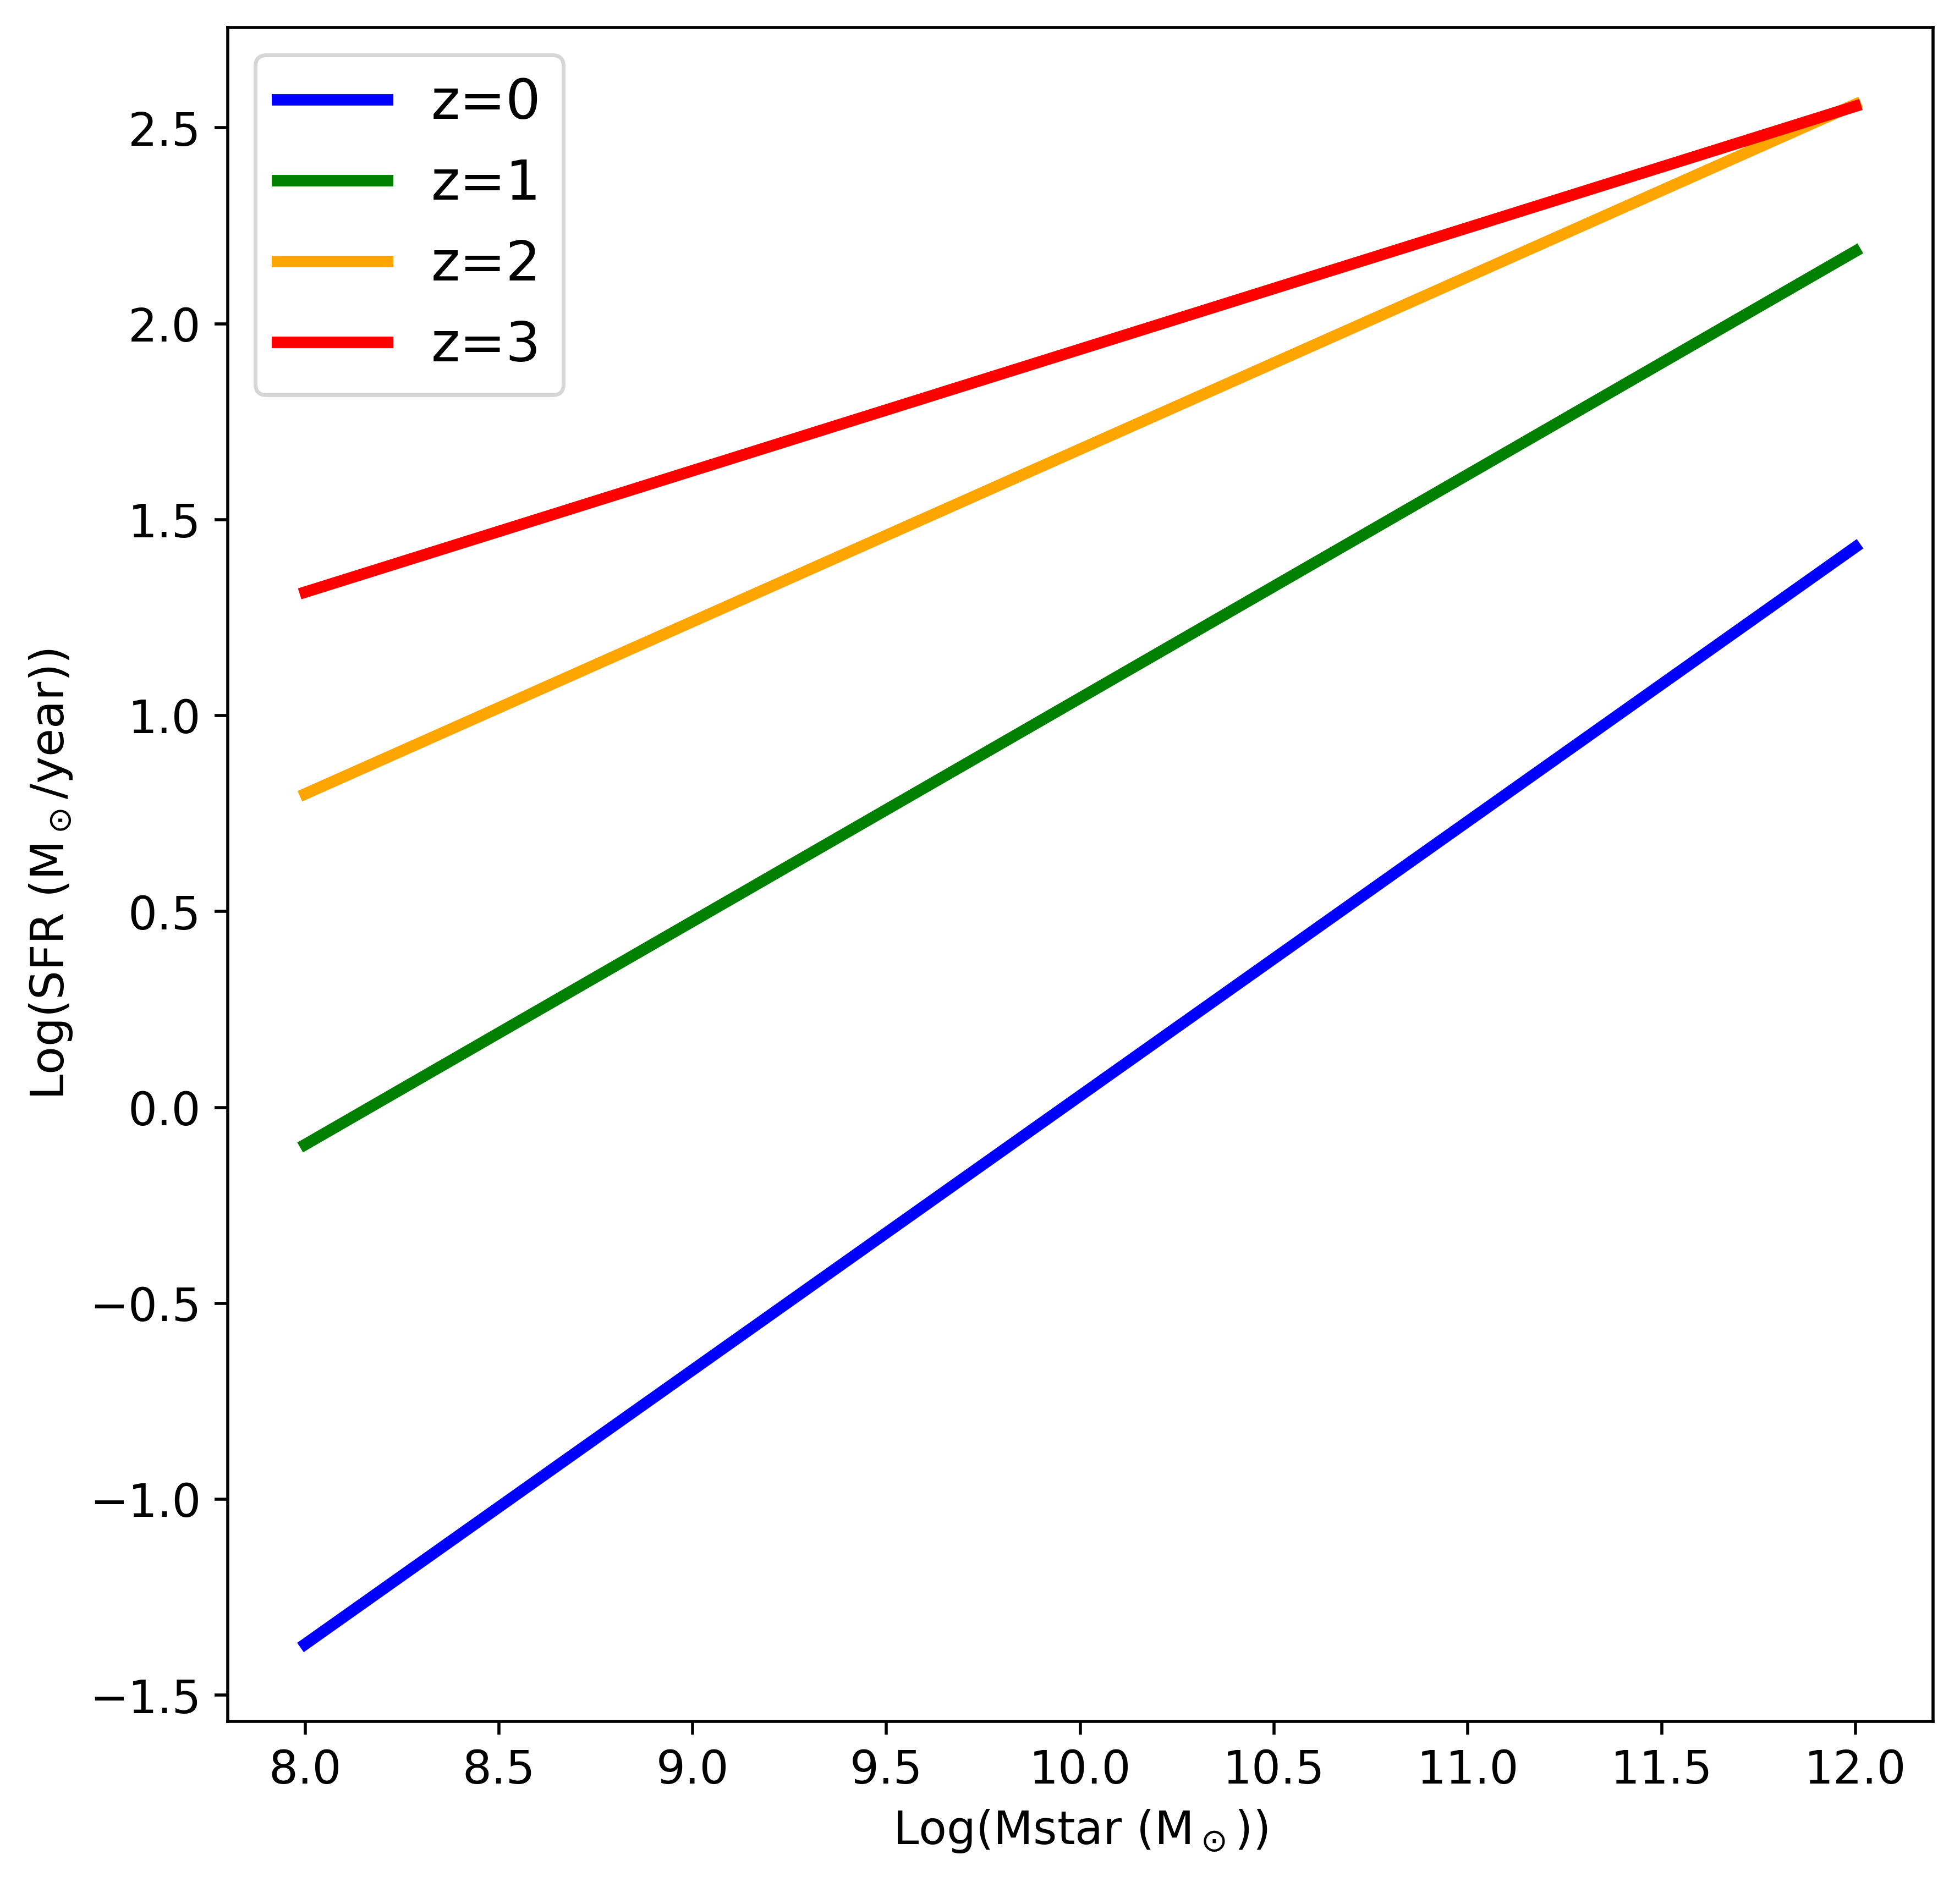

In [23]:

fig = plt.figure(figsize=(8,8), dpi=500)
ax = plt.subplot(111)

# add log log plots for z=0-3
plt.plot(np.log10(Mass), SFRMainSequence(Mass,0), color='blue', linewidth=3, label='z=0')
plt.plot(np.log10(Mass), SFRMainSequence(Mass,1), color='green', linewidth=3, label='z=1')
plt.plot(np.log10(Mass), SFRMainSequence(Mass,2), color='orange', linewidth=3, label='z=2')
plt.plot(np.log10(Mass), SFRMainSequence(Mass,3), color='red', linewidth=3, label='z=3')


# Add axis labels
plt.xlabel('Log(Mstar (M$_\odot$))', fontsize=12)
plt.ylabel('Log(SFR (M$_\odot$/year))', fontsize=12)


#adjust tick label font size
label_size = 12
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size

# add a legend with some customizations.
legend = ax.legend(loc='upper left',fontsize='x-large')


# Save file
plt.savefig('Lab8_SFR_MainSequence.png')

#can't maintain high star formation rates forever - ellipticals don't form lots of stars
#Total star formation is dominated by lower mass galaxies over time
#Get gas first then form stars then that settles and we have galaxies today
#Peak from z=1-3 is cosmic noon with lots of starbursts - peak of activity

# Part C  Starbursts

Use your `StarFormationRate` code to determine the typical star formation rates for the following systems with the listed Total Infrared Luminosities (TIR): 

Normal Galaxies: $10^{10}$ L$_\odot$

LIRG: $10^{11}$ L$_\odot$

ULIRG: $10^{12} $ L$_\odot$

HLIRG: $10^{13} $ L$_\odot$

In [24]:
# normal galaxies 
TIR_Normal = 1e10*LsunErgS
print(10**StarFormationRate(TIR_Normal, 'TIR'))

1.4892648150381245


In [ ]:
# LIRGs  


In [ ]:
# ULIRGs

In [26]:
# HLIRGs - hyper
TIR_HLIRG = 1e13*LsunErgS
print(10**StarFormationRate(TIR_HLIRG, 'TIR'))
#went from single digits to jumping to thousands!

1489.2648150381244
